# PyTorch Custom Datasets

(Date - 28/May/2026)

## 0. Importing torch and setting up device agnostic code

In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, dataset, Dataset
import requests
import zipfile
from pathlib import Path
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List

device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Getting the data

In [2]:
data_path = Path("FoodData/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory already exists. No need for downloading")
else:
    print(f"{image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print(f"downloading pizza, steak and sushi data...")
        f.write(request.content)

    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print(f"Unzipping pizza, steak and sushi data...")
        zip_ref.extractall(image_path)


FoodData\pizza_steak_sushi directory already exists. No need for downloading


## 2. Becoming one with the data

### 2.1 Walking through our directories

In [3]:
def walk_through_dir(dir_path):
    for dir_path, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dir_path}'")

In [4]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'FoodData\pizza_steak_sushi'
There are 3 directories and 0 images in 'FoodData\pizza_steak_sushi\test'
There are 0 directories and 25 images in 'FoodData\pizza_steak_sushi\test\pizza'
There are 0 directories and 19 images in 'FoodData\pizza_steak_sushi\test\steak'
There are 0 directories and 31 images in 'FoodData\pizza_steak_sushi\test\sushi'
There are 3 directories and 0 images in 'FoodData\pizza_steak_sushi\train'
There are 0 directories and 78 images in 'FoodData\pizza_steak_sushi\train\pizza'
There are 0 directories and 75 images in 'FoodData\pizza_steak_sushi\train\steak'
There are 0 directories and 72 images in 'FoodData\pizza_steak_sushi\train\sushi'


### 2.2 Setting up train and test paths

In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('FoodData/pizza_steak_sushi/train'),
 WindowsPath('FoodData/pizza_steak_sushi/test'))

### 2.3 Visualizing our images

Random image path: FoodData\pizza_steak_sushi\train\steak\2880035.jpg
Image class: steak
Image height: 512
Image width: 512


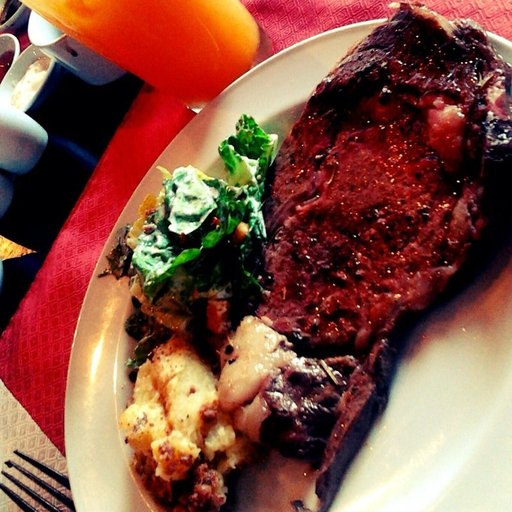

In [6]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(F"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

### 2.4 Plotting our image with matplotlib

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

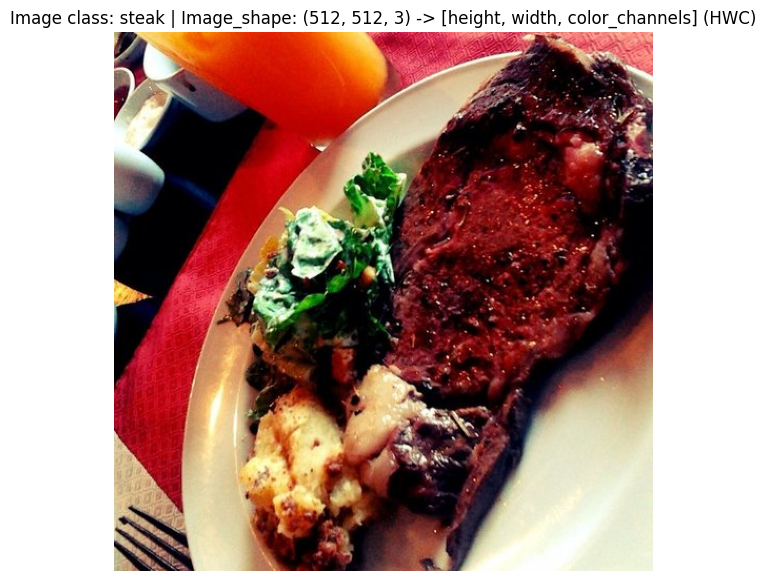

In [7]:
image_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image class: {image_class} | Image_shape: {image_as_array.shape} -> [height, width, color_channels] (HWC)")
plt.axis(False)

## 3. Transforming data

(Date - 29/May/2026)

### 3.1 Transforming data with `torchvision.transforms`

In [8]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [9]:
data_transform(img).shape

torch.Size([3, 64, 64])

In [10]:
def plot_transformed_image(image_paths, transform, n=3, seed=None):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """

    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize:: {f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1,2,0) # (C, H, W) -> (H, C, W)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off") # you may also write False instead of off

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

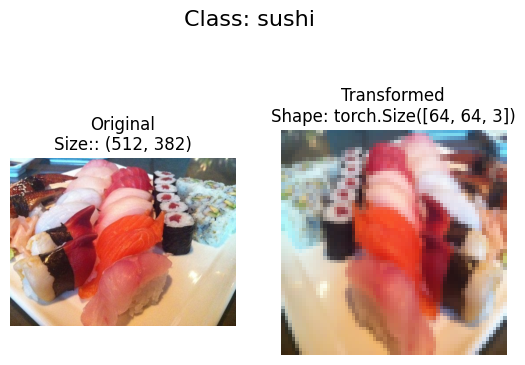

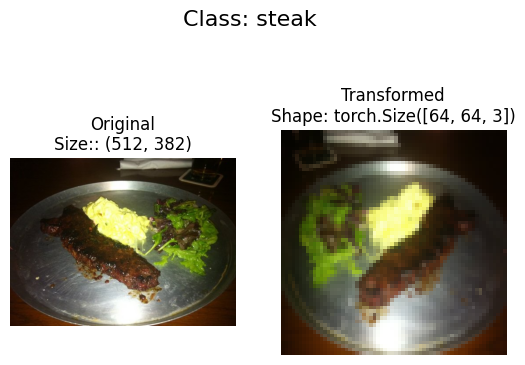

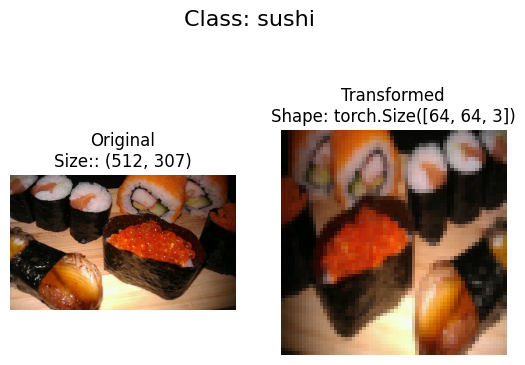

In [11]:
plot_transformed_image(image_paths=image_path_list,
                       transform=data_transform,
                       n=3,
                       seed=None)

(Date - 30/May/2026)

## 4. Option 1: Loading image data using `ImageFolder`

In [12]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: FoodData\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: FoodData\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [13]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [14]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [15]:
len(train_data), len(test_data)

(225, 75)

In [16]:
train_data.samples[0]

('FoodData\\pizza_steak_sushi\\train\\pizza\\1008844.jpg', 0)

In [17]:
img, label = train_data[0][0], train_data[0][1]
print(f"image tensor:\n{img}\n")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label} ({class_names[label]})")
print(f"Label datatype {type(label)}")

image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [18]:
class_names[label]

'pizza'

Original shape: torch.Size([3, 64, 64]) -> [Color Channels, Height, width]
image permute: torch.Size([64, 64, 3]) -> [Height, Width, Color Channels]


Text(0.5, 1.0, 'pizza')

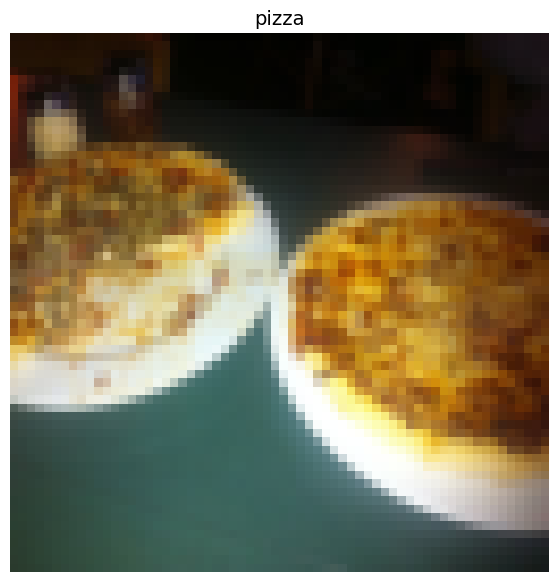

In [19]:
img_permute = img.permute(1,2,0)

print(f"Original shape: {img.shape} -> [Color Channels, Height, width]")
print(f"image permute: {img_permute.shape} -> [Height, Width, Color Channels]")

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("OFF")
plt.title(class_names[label], fontsize=14)

### 4.1 Preparing Data Loader

In [20]:
BATCH_SIZE = 1
train_dataloader = DataLoader(dataset=train_data,
                              shuffle=True,
                              num_workers=1, # You may also write : num_workers = os.cpu_count()
                              batch_size=BATCH_SIZE)

test_dataloader = DataLoader(dataset=test_data,
                              shuffle=False,
                              num_workers=1,
                              batch_size=BATCH_SIZE)

len(train_dataloader), len(test_dataloader)

(225, 75)

In [21]:
img, label = next(iter(train_dataloader))

print(f"Train Image shape: {img.shape} -> [color channels, height width]")
print(f"Label shape: {label.shape}")

Train Image shape: torch.Size([1, 3, 64, 64]) -> [color channels, height width]
Label shape: torch.Size([1])


## 5. Option 2: Loading Image Data with a Custom `Dataset`

(Date - 31/May/2026)

In [22]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

We want a function to:
1. Get the class name using `os.scandir()` to transverse a target dictionary (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found.
3. Turn the classes names into a dict and a list, and return them.

In [23]:
target_directory = train_dir
print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: FoodData\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [24]:
os.scandir(target_directory)

In [25]:
list(os.scandir(target_directory))

[<DirEntry 'pizza'>, <DirEntry 'steak'>, <DirEntry 'sushi'>]

In [26]:
for entry in list(os.scandir(target_directory)):
    print(entry,"\t", entry.name,"\t", entry.__class__)

<DirEntry 'pizza'> 	 pizza 	 <class 'nt.DirEntry'>
<DirEntry 'steak'> 	 steak 	 <class 'nt.DirEntry'>
<DirEntry 'sushi'> 	 sushi 	 <class 'nt.DirEntry'>


In [27]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folder names in a target directory.
    
    Assumes target directory is in standard image classification format.

    Args:
        directory (str): target directory to load class names from.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))
    
    Example:
        find_classes("food_images/train")
         (["class_1", "class_2"], {"class_1": 0, ...})

    """
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}... Please check file structure")
    
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}

    return classes, class_to_idx

In [28]:
find_classes(directory=target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create our own custom dataset, we will have to:
1. Subclass torch.utils.data.Dataset.
2. Initialize our subclass with a targ_dir parameter (the target data directory) and transform parameter (so we have the option to transform our data if needed).
3. Create several attributes for paths (the paths of our target images), transform (the transforms we might like to use, this can be None), classes and class_to_idx (from our find_classes() function).
4. Create a function to load images from file and return them, this could be using PIL or torchvision.io (for input/output of vision data).
5. Overwrite the __len__ method of torch.utils.data.Dataset to return the number of samples in the Dataset, this is recommended but not required. This is so you can call len(Dataset).
6. Overwrite the __getitem__ method of torch.utils.data.Dataset to return a single sample from the Dataset, this is required.

(Date - 1/June/2026)

In [29]:
class ImageFolderCustom(Dataset):
    def __init__(self,
               targ_dir:str,
               transform=None):
        
        self.paths = list(Path(targ_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index:int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path)

    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        img = self.load_image(index)
        class_name = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_name]

        if self.transform:
            return self.transform(img), class_idx
        else:
            return img, class_idx

In [30]:
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [31]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                  transform=train_transform)

test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transform)

In [32]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x156e2617b90>,
 <__main__.ImageFolderCustom at 0x156e2643250>)

In [33]:
len(train_data), len(train_data_custom)

(225, 225)

In [34]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [35]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

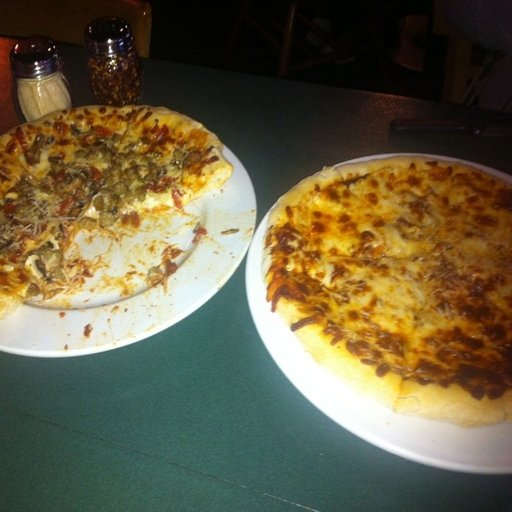

In [36]:
train_data_custom.load_image(index=0)

In [37]:
print(train_data_custom.classes == train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True


### 5.3 Creating a function to display random images

(Date - 2/Jun/2026)

In [38]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str]=None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    if n>10:
        n = 10
        display_shape = False
        print(f"For display purpose, n shouldn't be larger than 10, setting to 10 and removing shape display...")

    if seed:
        random.seed(seed)
    
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16,8))

    for i, targ_sample in enumerate(random_samples_idx):
        targ_img, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        targ_image_adjust = targ_img.permute(1,2,0)

        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

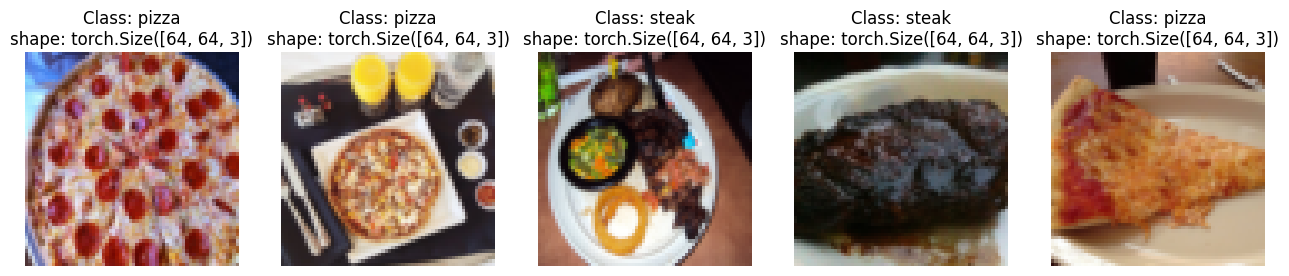

In [39]:
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      display_shape=True,
                      seed=None)

For display purpose, n shouldn't be larger than 10, setting to 10 and removing shape display...


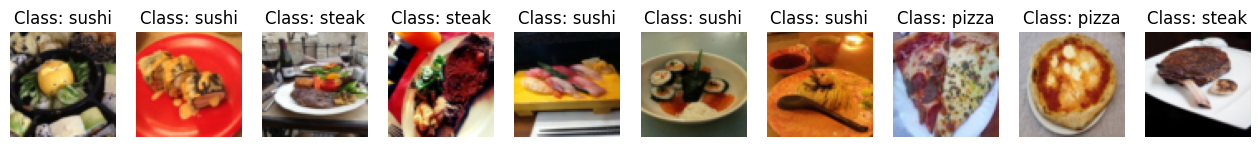

In [40]:
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=None)

### 5.4 Turn custom loaded images into `DataLoaders.`

(Date - 3/June/2026)

In [41]:
BATCH_SIZE = 1
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                              num_workers=0,
                              shuffle=True,
                              batch_size=BATCH_SIZE)

test_dataloader_custom = DataLoader(dataset=test_data_custom,
                              num_workers= os.cpu_count(), # cpu count = 1
                              shuffle=True,
                              batch_size=BATCH_SIZE)

train_dataloader_custom, test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x156e2643310>,
 <torch.utils.data.dataloader.DataLoader at 0x156e3b9ed90>)

In [42]:
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

## 6. Other forms of transforms (data augmentation)

(Date - 4/June/2026)

Data augmentation is the process of artificially adding diversity to your training data.

### 6.1 Trivial augment

In [49]:
train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
    ])

In [50]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('FoodData/pizza_steak_sushi/test/pizza/2124579.jpg')]

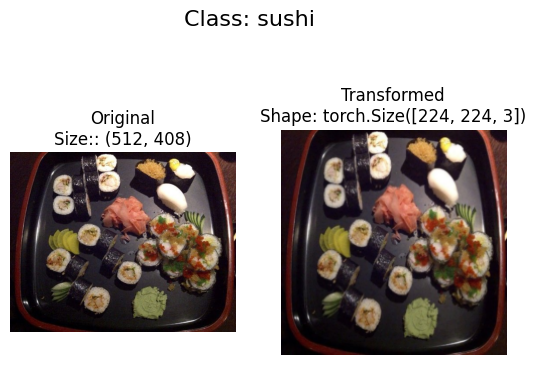

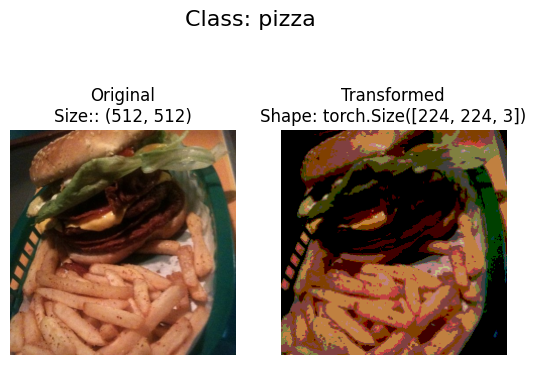

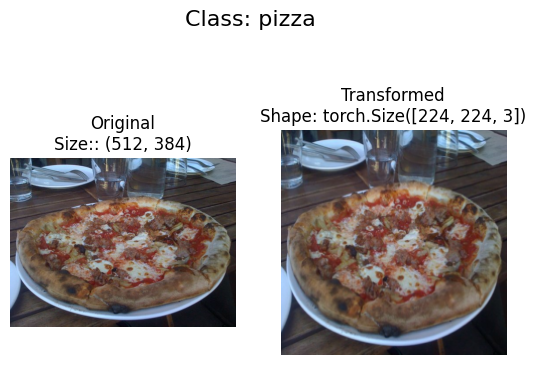

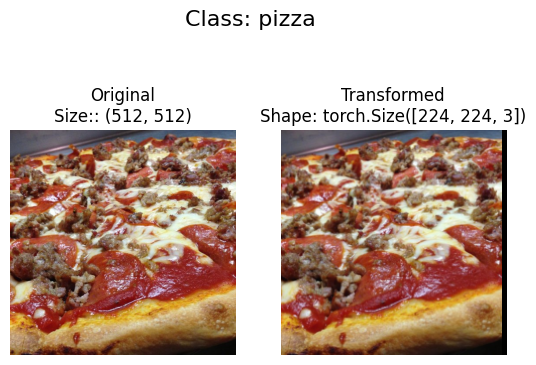

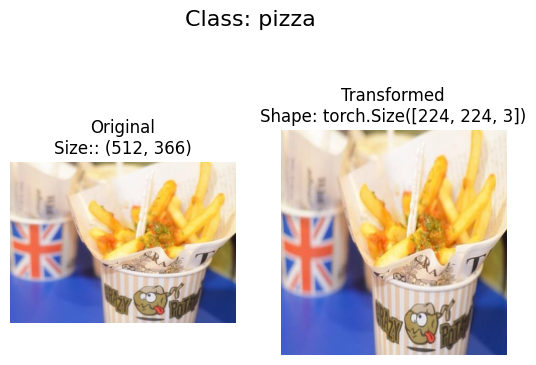

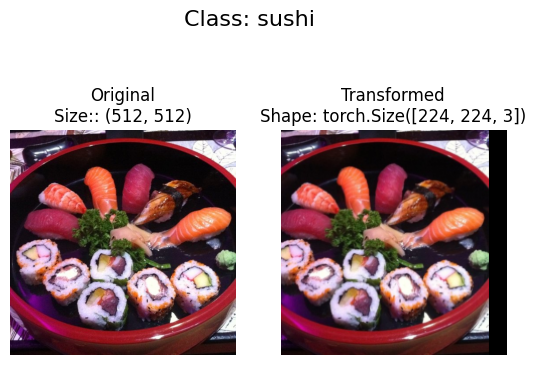

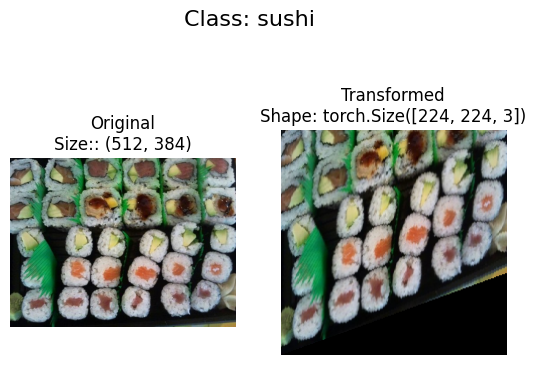

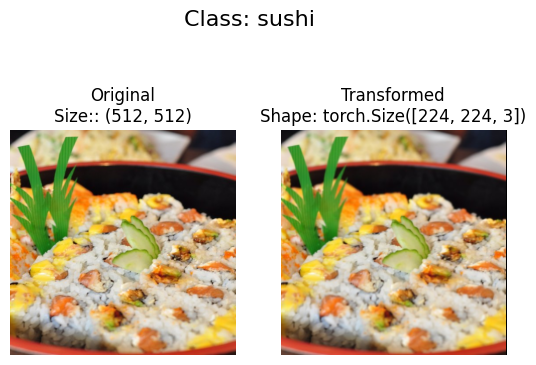

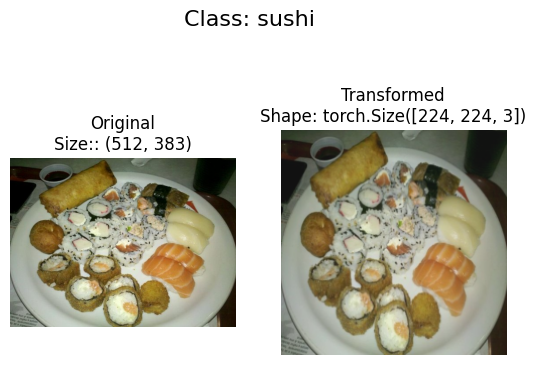

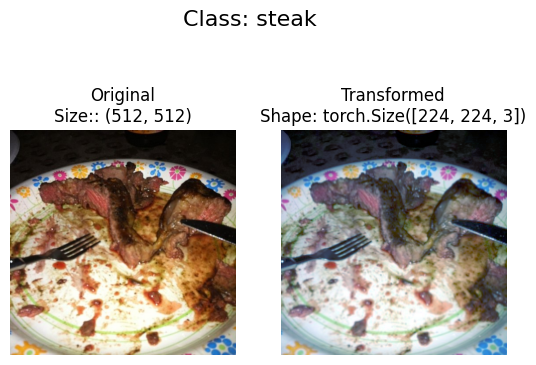

In [51]:
plot_transformed_image(
    image_paths = image_path_list,
    transform=train_transform,
    n=10,
    seed=42
)